# Imports

In [55]:
import numpy as np
import torch 
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

import sigkernel as ksig_pde
import sigkernel_ as ksig_disc

from generators.synthetic_generators import *
from generators.ESN import ESNGenerator, ESNAsTarget
from generators.TheoremAESN import TheoremAESN
from models.trainer_ESN_LBFGS import fit_ESN_MMD_LBFGS

from loss.loss import compute_mmd_loss

from utils.kernel_helpers import median_heuristic_sigma, tune_tau_coef_for_cv
from utils.analyse_controlled_experiments import *
from utils.analyse_results import *
from utils.data import *

%load_ext autoreload
%autoreload 2

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
dtype=torch.float64

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
torch.manual_seed(0)  

# Generators

Initialize ESN and target ESN parameters.

In [57]:
T = 100 # length of time series
N = 100  # number of samples (for target)
N_esn = 2000
T_long_for_eval = 1000

target_type = "returns" # choice of target type: "returns", "log_returns", "sqrd_log_returns"
noise_seed = 0

In [58]:
# Shared config for TheoremAESN (autoregressive, single-readout, cold-start)
h, d = 500, 1                  # reservoir size, output dim
noise_dim = 1                  # Unif[-1,1] PIT channels per step (1 for scalar output)
readout = "nonlinear"             # readout type: "linear" or "nonlinear" (shallow NN)
readout_hidden = 128            # hidden width for shallow NN readout (if readout="nonlinear")
readout_activation = "asinh"    # activation for shallow NN readout (if readout="nonlinear")
noise = Noise("uniform")       # reservoir-input noise; None -> Unif[noise_low, noise_high] | Noise("normal") | Noise("t",{"df":4}) 

target_spectral_norm = 0.9     # ||A||_2 ; MUST be < 1 for tanh (stability + echo-state)
activation = "tanh"            # squashing activation required (NOT "none")

sparsity = 1.0                 # fraction of nonzero A entries; optional ESN convention (1.0 = dense is fine)
C_scale = 0.7                  # input-drive strength / tanh operating regime (drop to ~0.3 if over-driven)
zeta_scale = 0.0               # reservoir bias OFF -> stays centered; set >0 ONLY for skewed targets
W_init_std = 0.1               # readout init ~ order of target std; training tunes from here
lags = 1                       # k-Markov state augmentation (1 = no augmentation)
skip_scale = 0.0               # gain on output skip innovation; 0 -> OFF (v does not learn)

washout_len = h                # burn-in; h is conservatively large

### AR2

In [59]:
p = 2   # AR order
q = 0   # MA order
phi = [0.7, -0.2] # AR coefficients
theta = None # MA coefficients
burnin = 50 # number of initial samples to discard to mitigate initialization effects

target_generator = ARMA(T=T, p=p, q=q, phi=phi, theta=theta, d=d, burnin=burnin, noise=Noise("truncated_normal", {"c":2.5}))

### Markov Tilted Uniform

In [60]:
# # --- in-assumption k-Markov target: satisfies Theorem A's compact-support + bounded-density hypotheses ---
# w = [0.6, -0.3]   # tilt weights; len(w) = k = Markov order (here 2, to mirror AR2)
# b = 0.8           # tilt strength in (0,1); larger -> stronger dependence (keeps |beta| < b < 1)
# M = 1.0           # compact support [-M, M]
# burnin = 300      # discard to reach the stationary law

# target_generator = MarkovTiltedUniform(T=T, w=w, b=b, M=M, d=d, burnin=burnin)

In [61]:
# ESN estimator (Theorem A model: cold-start, output feedback, single readout W)
esn = TheoremAESN(
    h_dim=h, out_dim=d,
    target_spectral_norm=target_spectral_norm, activation=activation,
    C_scale=C_scale, W_init_std=W_init_std, washout_len=washout_len, seed=0, sparsity=sparsity, zeta_scale=zeta_scale,

    readout=readout, readout_hidden=readout_hidden, readout_activation=readout_activation,     # (4) readout
    noise=noise, noise_dim=noise_dim,                                                          # (1) noise
    feedback_lags=lags,                                                                        # (2) k-Markov state augmentation
    skip_scale=skip_scale,                                                                     # (3) Gaussian tail skip
)

# Kernels

In [62]:
with torch.no_grad():
    Z_target_raw = target_generator.generate(T=T, N=N).to(device=device, dtype=dtype)
    Z_esn_raw = esn(T=T, N=N_esn).to(device=device, dtype=dtype)

# Apply the selected target transformation
eps = 1e-8

if target_type == "returns":
    Z_target = Z_target_raw
    Z_esn = Z_esn_raw
elif target_type == "log_returns":
    Z_target = torch.log1p(Z_target_raw) # this doesnt make sense with real returns (I need percentage returns)
    Z_esn = torch.log1p(Z_esn_raw)
elif target_type == "sqrd_log_returns": # this doesnt make sense with real returns (I need percentage returns)
    log_r = torch.log1p(Z_target_raw)
    Z_target = log_r ** 2
    Z_esn = torch.log1p(Z_esn_raw) ** 2
elif target_type == "log_sqrd_returns":
    Z_target = torch.log(Z_target_raw ** 2 + eps)
    Z_esn = torch.log(Z_esn_raw ** 2 + eps)

print(f"Generated data shapes: Z_target: {Z_target.shape}, Z_esn: {Z_esn.shape}")
_median_heuristic_sigma = median_heuristic_sigma(Z_target, Z_esn)
print(f"Median heuristic sigma: {_median_heuristic_sigma:.6f}")

Generated data shapes: Z_target: torch.Size([100, 100, 1]), Z_esn: torch.Size([2000, 100, 1])
Median heuristic sigma: 19.991522


In [63]:
# Define the discretized signature kernel
static_kernel_type    = 'rbf' # type of static kernel to use - rbf, rbfmix, rq, rqmix, rqlinear for
n_levels              = 10 # number of levels in the truncated signature kernel
disc_sig_kernel_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel

sig_disc_kernel = ksig_disc.kernels.get_discretized_signature_kernel(**{'static_kernel_type': static_kernel_type, 'n_levels': n_levels, 'kernel_sigma': disc_sig_kernel_sigma})

#---------------------------------
# Define the pde signature kernel
pde_sig_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel
static_kernel = ksig_pde.RBFKernel(sigma=pde_sig_sigma) # define static kernel

sig_pde_kernel = ksig_pde.SigKernel(static_kernel, dyadic_order=0)

#---------------------------------
# Define static kernel
static_sigma = _median_heuristic_sigma # bandwidth parameter for the static kernel

rbf_kernel = ksig_disc.kernels.RBFKernel(sigma=static_sigma)

#---------------------------------
# # Volterra kernel
# ld_coef = 0.7
# tau_best, cv_best, spec_best = tune_tau_coef_for_cv(X, ld_coef=ld_coef)
# tau_coef = tau_best
# volterra_kernel = ksig_disc.kernels.VolterraKernel(ld_coef=ld_coef, tau_coef=tau_coef)
# volterra_kernel.fit(X) # fitting is needed to compute lambda, tau and the normalization constant
# print(f"Best tau: {tau_best}, CV: {cv_best}")

## Choose kernel

Choose one kernel

In [64]:
# kernel = sig_disc_kernel      # discretized signature kernel
# kernel = sig_pde_kernel        # pde signature kernel
kernel = rbf_kernel           # static kernel
# kernel = volterra_kernel      # volterra kernel

Run initial MMD to check and as a baseline

In [65]:
if "sig" in kernel.__class__.__name__.lower() or "volt" in kernel.__class__.__name__.lower():
    kernel_mode = "sequential"
else:
    kernel_mode = "static"

print(f"Using kernel: {kernel.__class__.__name__} with kernel mode: {kernel_mode}")

# initial mmd:
initial_mmd = compute_mmd_loss(kernel, Z_target, Z_esn) if kernel_mode == "sequential" else compute_mmd_loss(kernel, Z_target.reshape(Z_target.shape[0], -1), Z_esn.reshape(Z_esn.shape[0], -1))
print(f"Initial MMD with {kernel.__class__.__name__} kernel: {initial_mmd:.6f}")

Using kernel: RBFKernel with kernel mode: static
Initial MMD with RBFKernel kernel: 0.009201


# Statistical Analysis Before Fitting

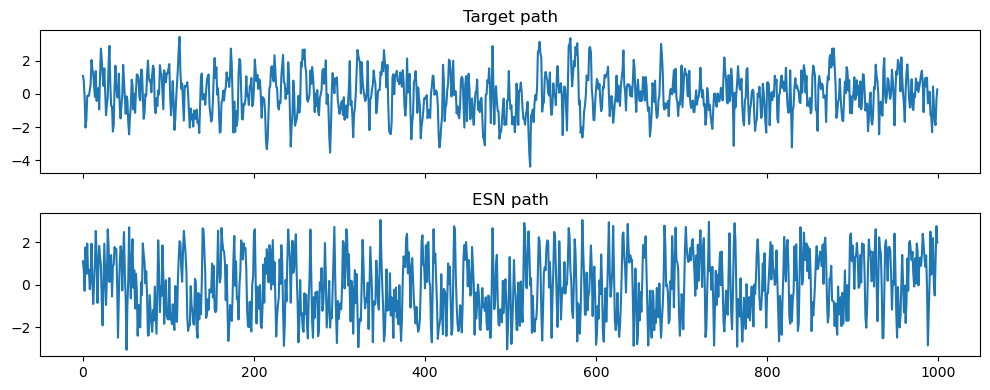

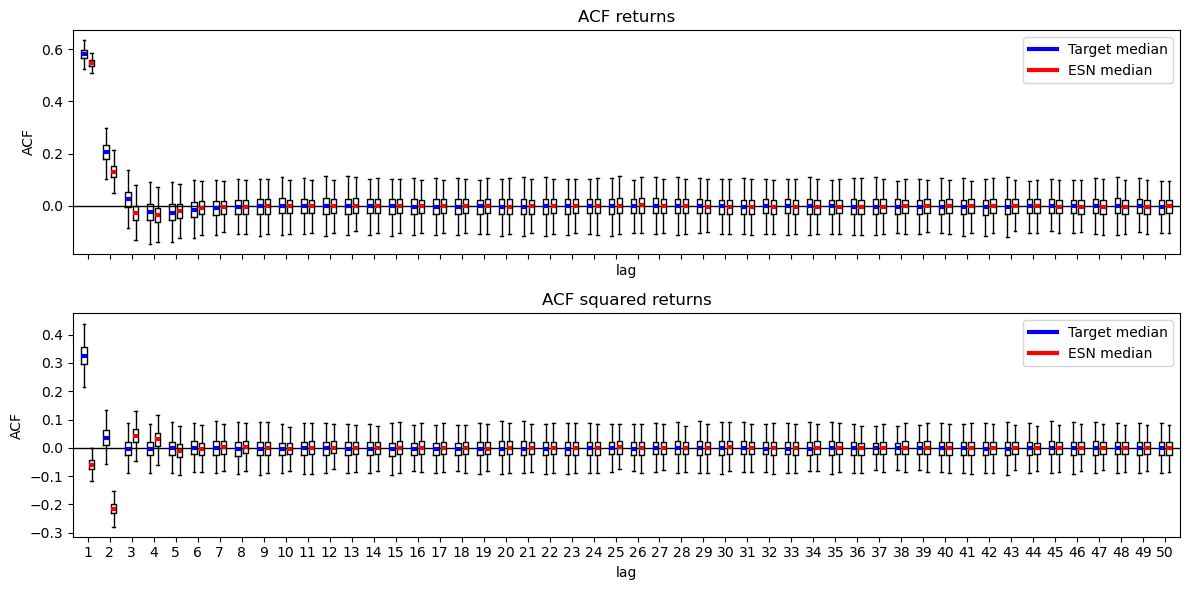

In [66]:
# run ACF analysis (plots + curves)
N_acf = 1000
T_acf = 1000
lag_acf = 50
acf_out = acf_analysis(
    esn,
    target_generator=target_generator,
    N=N_acf,
    T=T_acf,
    lag=lag_acf,
    component=0,
    device=device,
    dtype=dtype,
)

# New training loop (now cannot fix history)

In [67]:
import torch
from loss.loss import compute_mmd_loss


def fit_ESN_MMD_BPTT(
    *,
    esn,
    Z_target,
    kernel,
    kernel_mode,            # "static" or "sequential"
    N_model,
    lead_lag=False,
    lags=0,
    optimizer="lbfgs",      # "lbfgs" or "adam"
    max_iter=500,           # LBFGS: inner max_iter ; Adam: number of steps
    lr=0.1,
    history_size=20,
    reg_lambda=1e-3,
    force_float64=True,
    target_type=None,
    x_init=None,
    fixed_noise=True,       # sample drives once, hold fixed (deterministic objective for LBFGS)
    noise_seed=None,
    keep_best=True,         # restore params at the LOWEST loss seen (else you keep the last iterate)
    verbose=True,
):
    """
    Full-BPTT MMD trainer for TheoremAESN. Runs forward INSIDE the loss, so autograd
    differentiates through the recurrence (output feedback + lag augmentation). Optimizes
    ALL trainable params: W, v (if skip_scale>0), and W_sigma (if readout='nonlinear').
    Updates esn IN PLACE. With keep_best, restores the lowest-loss params at the end.
    """
    if Z_target.ndim != 3:
        raise ValueError("Z_target must be (N_target, T, d)")
    N_target, T, d = Z_target.shape

    device = esn.A.device
    dtype = torch.float64 if force_float64 else esn.A.dtype
    esn = esn.to(device=device, dtype=dtype).eval()
    Z_target = Z_target.to(device=device, dtype=dtype)
    if int(esn.d) != int(d):
        raise ValueError(f"esn.d={int(esn.d)} != Z_target d={int(d)}")

    # everything trainable: W always; v iff skip on; W_sigma iff nonlinear readout
    params = [p for p in esn.parameters() if p.requires_grad]

    # fixed drives -> deterministic objective across closure evals (LBFGS needs this)
    u = us = None
    if fixed_noise:
        g = torch.Generator(device=device).manual_seed(int(noise_seed)) if noise_seed is not None else None
        u = esn.sample_noise(N_model, T, generator=g)
        if esn.skip_scale != 0:
            us = esn.sample_skip_noise(N_model, T, generator=g)

    eps = 1e-8
    def _tf(Z):
        if target_type in (None, "returns"):  return Z
        if target_type == "log_returns":       return torch.log1p(Z)
        if target_type == "sqrd_log_returns":  return torch.log1p(Z) ** 2
        if target_type == "log_sqrd_returns":  return torch.log(Z ** 2 + eps)
        raise ValueError(f"unknown target_type: {target_type}")

    Z_tgt = _tf(Z_target)

    def loss_fn():
        Zm = _tf(esn(T=T, N=N_model, x_init=x_init, xi=u, xi_skip=us))   # grad flows to all params
        if kernel_mode == "static":
            Xk, Yk = Z_tgt.reshape(N_target, -1), Zm.reshape(N_model, -1)
        else:
            Xk, Yk = Z_tgt, Zm
        # regularize only the output readout weight W (don't suppress the skip weight v)
        return compute_mmd_loss(kernel, Xk, Yk, lead_lag, lags) + reg_lambda * torch.linalg.norm(esn.W)

    loss_history = []
    best = {"loss": float("inf"), "state": None}
    def _record(L):
        loss_history.append(L)
        if keep_best and L < best["loss"]:
            best["loss"] = L
            best["state"] = [p.detach().clone() for p in params]

    with torch.no_grad():
        m0 = float(loss_fn())
    if verbose:
        print("MMD initial:", m0)

    if optimizer.lower() == "lbfgs":
        opt = torch.optim.LBFGS(params, lr=lr, max_iter=max_iter, history_size=history_size,
                                line_search_fn="strong_wolfe")
        def closure():
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(); loss.backward()
            L = loss.item(); _record(L)
            if verbose and len(loss_history) % 50 == 0:
                print(f"Eval {len(loss_history)}: Loss {L:.6e}")
            return loss
        opt.step(closure)

    elif optimizer.lower() == "adam":
        opt = torch.optim.Adam(params, lr=lr)
        for step in range(int(max_iter)):
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(); loss.backward(); opt.step()
            L = loss.item(); _record(L)
            if verbose and (step + 1) % 50 == 0:
                print(f"Step {step+1}: Loss {L:.6e}")
    else:
        raise ValueError("optimizer must be 'lbfgs' or 'adam'")

    # the optimizer leaves params at the LAST iterate; restore the best if asked
    if keep_best and best["state"] is not None:
        with torch.no_grad():
            for p, b in zip(params, best["state"]):
                p.copy_(b)

    with torch.no_grad():
        m1 = float(loss_fn())
    if verbose:
        print("MMD final:", m1, "(best restored)" if keep_best else "(last iterate)")

    return {
        "mmd_initial": m0,
        "mmd_final": m1,
        "mmd_best": best["loss"] if keep_best else min(loss_history),
        "loss_history": loss_history,
        "W_fit": esn.W.detach().cpu().clone(),
        "T": int(T), "N_target": int(N_target), "N_model": int(N_model), "dtype": str(dtype),
    }

# Fit ESN

In [ ]:
print(f"Using kernel: {kernel.__class__.__name__} with kernel mode: {kernel_mode}")

N_train = 512   # paths inside the MMD during training (BPTT memory ~ (washout+T) x N_train x h)

results = fit_ESN_MMD_BPTT(
    esn=esn,
    Z_target=Z_target,
    kernel=kernel,
    kernel_mode=kernel_mode,
    N_model=N_train,
    lead_lag=False, lags=0,
    optimizer="lbfgs",       # "adam" if LBFGS is too heavy
    max_iter=1000,
    lr=0.1,
    reg_lambda=1e-3,
    force_float64=True,
    target_type=target_type,
    fixed_noise=True, noise_seed=noise_seed,
    keep_best=False,          # <- restores the lowest-loss params at the end
    verbose=True,
)
print(f"MMD {results['mmd_initial']:.6e} -> {results['mmd_final']:.6e}  (best {results['mmd_best']:.6e})")

Using kernel: RBFKernel with kernel mode: static
MMD initial: 0.011175998979754262
Eval 50: Loss 1.452810e-03
Eval 100: Loss 1.161112e-03
Eval 150: Loss 9.828982e-04
Eval 200: Loss 8.643755e-04
Eval 250: Loss 7.148971e-04
Eval 300: Loss 6.387876e-04
Eval 350: Loss 5.432925e-04
Eval 400: Loss 4.934647e-04
Eval 450: Loss 4.641115e-04
Eval 500: Loss 4.328572e-04
Eval 550: Loss 4.102547e-04
Eval 600: Loss 3.934721e-04
Eval 650: Loss 3.679082e-04


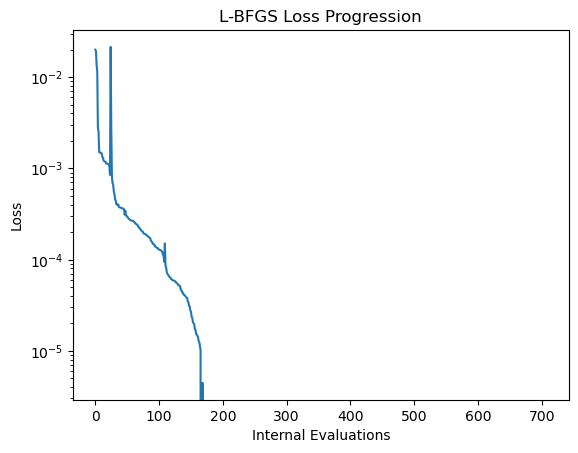

In [ ]:
loss_history = results['loss_history']
plt.plot(loss_history)
plt.xlabel('Internal Evaluations')
plt.ylabel('Loss')
plt.title('L-BFGS Loss Progression')
plt.yscale('log') # Useful if loss drops several orders of magnitude
plt.show()

# Statistical Analysis After Fitting

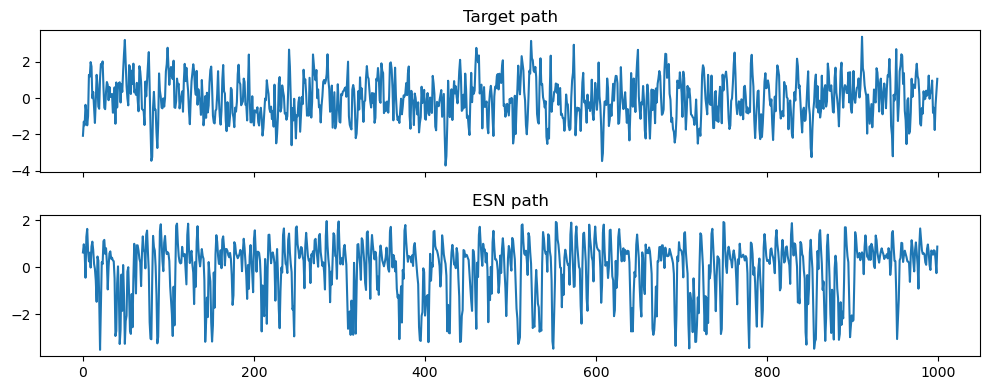

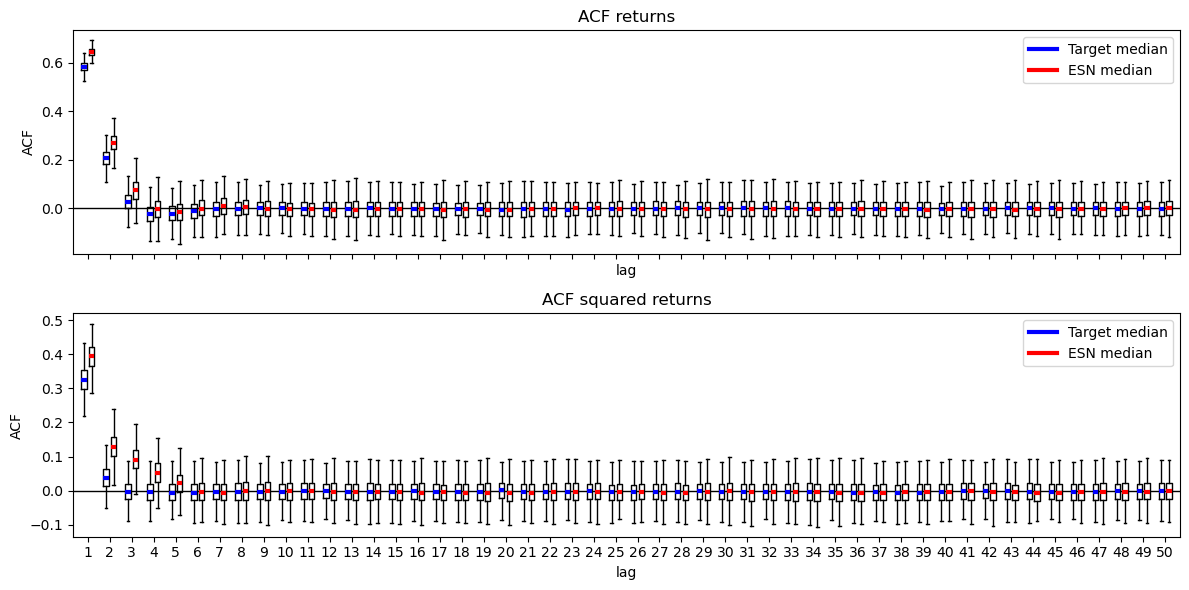

acf_target first 10: [ 0.56355714  0.19229279  0.02231223 -0.03949916 -0.05114067 -0.01604006
 -0.00529608 -0.01503376 -0.05312979 -0.05526828]
acf_esn first 10: [ 0.66198227  0.31071943  0.09243033 -0.02804972 -0.05250614 -0.02766254
  0.0200098   0.04416533  0.04507891  0.02856486]


In [ ]:
# run ACF analysis (plots + curves)
N_acf = 1000
T_acf = 1000
lag_acf = 50
acf_out = acf_analysis(
    esn,
    target_generator=target_generator,
    N=N_acf,
    T=T_acf,
    lag=lag_acf,
    component=0,
    device=device,
    dtype=dtype,
)


print("acf_target first 10:", acf_out["acf_target"].ravel()[:10])
print("acf_esn first 10:", acf_out["acf_esn"].ravel()[:10])

In [ ]:
# target
phis_tgt, thetas_tgt = fit_arma_on_paths(Z_target[...,0], p=2, q=0)

# esn
with torch.no_grad():
    Z_esn = esn(T=T_long_for_eval, N=N_esn).cpu().numpy()

phis_esn, thetas_esn = fit_arma_on_paths(Z_esn[...,0], p=2, q=0)

# compare
print("target:", summarize_params(phis_tgt, thetas_tgt))
print("esn:", summarize_params(phis_esn, thetas_esn))

target: {'phi_mean': array([ 0.6927705 , -0.20704283]), 'phi_std': array([0.0916468 , 0.08777422]), 'phi_median': array([ 0.68856617, -0.20362262])}
esn: {'phi_mean': array([ 0.81026672, -0.25158313]), 'phi_std': array([0.02982336, 0.03563651]), 'phi_median': array([ 0.81073786, -0.25285933])}


  stat |     target |        ESN
----------------------------------
  mean |     0.0006 |     0.0119
   std |     1.1998 |     1.1987
   min |    -4.6855 |    -3.6392
   max |     4.9210 |     2.1268
  q005 |    -2.9906 |    -3.3674
   q01 |    -2.7352 |    -3.2548
   q99 |     2.7445 |     1.8354
  q995 |     3.0053 |     1.9110
  skew |     0.0031 |    -1.0670
  kurt |     2.8161 |     3.5021

Tail reach:
  target range [-4.69, +4.92]   ESN range [-3.64, +2.13]
  |ESN max|/|target max| = 43.2%   |ESN min|/|target min| = 77.7%


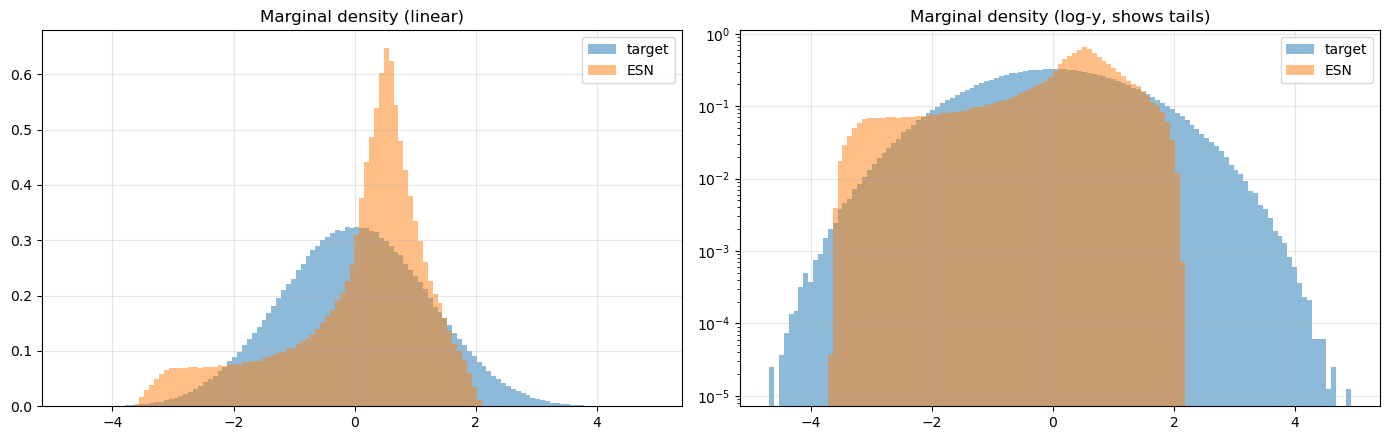

In [ ]:
# ===== Post-training diagnostic: marginal distribution (target vs ESN) =====
import numpy as np

N_diag, T_diag = 1000, 1000

with torch.no_grad():
    Zt = target_generator.generate(T=T_diag, N=N_diag).to(device=device, dtype=dtype)
    Ze = esn(T=T_diag, N=N_diag).to(device=device, dtype=dtype)

# apply the same target transform used in training, so the comparison is like-for-like
def _tf(Z):
    if target_type in (None, "returns"):     return Z
    if target_type == "log_returns":          return torch.log1p(Z)
    if target_type == "sqrd_log_returns":     return torch.log1p(Z) ** 2
    if target_type == "log_sqrd_returns":     return torch.log(Z ** 2 + 1e-8)
    return Z

t = _tf(Zt)[..., 0].reshape(-1).cpu().numpy()
e = _tf(Ze)[..., 0].reshape(-1).cpu().numpy()

def _summ(x):
    x = np.asarray(x, np.float64); m, s = x.mean(), x.std(); z = (x - m) / (s + 1e-12)
    return dict(mean=m, std=s, min=x.min(), max=x.max(),
                q005=np.quantile(x, 0.005), q01=np.quantile(x, 0.01),
                q99=np.quantile(x, 0.99), q995=np.quantile(x, 0.995),
                skew=(z**3).mean(), kurt=(z**4).mean())   # kurt raw: Gaussian = 3

st, se = _summ(t), _summ(e)
cols = ["mean", "std", "min", "max", "q005", "q01", "q99", "q995", "skew", "kurt"]
print(f"{'stat':>6} | {'target':>10} | {'ESN':>10}"); print("-" * 34)
for c in cols:
    print(f"{c:>6} | {st[c]:>10.4f} | {se[c]:>10.4f}")

print("\nTail reach:")
print(f"  target range [{st['min']:+.2f}, {st['max']:+.2f}]   ESN range [{se['min']:+.2f}, {se['max']:+.2f}]")
print(f"  |ESN max|/|target max| = {abs(se['max'])/(abs(st['max'])+1e-12):.1%}"
      f"   |ESN min|/|target min| = {abs(se['min'])/(abs(st['min'])+1e-12):.1%}")

lo, hi = min(st['min'], se['min']), max(st['max'], se['max'])
bins = np.linspace(lo, hi, 120)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for a, yl in [(ax[0], None), (ax[1], 'log')]:
    a.hist(t, bins=bins, density=True, alpha=0.5, label='target')
    a.hist(e, bins=bins, density=True, alpha=0.5, label='ESN')
    if yl: a.set_yscale('log')
    a.legend(); a.grid(alpha=0.3)
ax[0].set_title('Marginal density (linear)')
ax[1].set_title('Marginal density (log-y, shows tails)')
plt.tight_layout(); plt.show()